In [9]:
import subprocess
import os

SUBMIT_DIR = os.path.expanduser("/home/admin/cluster_benchmark")

def submit(submit_file):
    result = subprocess.run(
        ["condor_submit", submit_file],
        capture_output=True, text=True,
        cwd=SUBMIT_DIR 
    )
    print(result.stdout or result.stderr)

# submit("cpu_single.submit")
submit("stress.submit")
# "cpu_parrallel.submit"
# for f in ["cpu_single.submit", "memory.submit", "io.submit", "stress.submit"]:
#     submit(f)

Submitting job(s)....................................
36 job(s) submitted to cluster 110.



In [63]:
def submit_dag(dag_file):
    result = subprocess.run(
        ["condor_submit_dag", dag_file],
        capture_output=True, text=True,
        cwd=SUBMIT_DIR
    )
    print(result.stdout or result.stderr)

submit_dag("stress_test.dag")

Submitting job(s).
1 job(s) submitted to cluster 99.

-----------------------------------------------------------------------
File for submitting this DAG to HTCondor           : stress_test.dag.condor.sub
Log of DAGMan debugging messages                   : stress_test.dag.dagman.out
Log of HTCondor library output                     : stress_test.dag.lib.out
Log of HTCondor library error messages             : stress_test.dag.lib.err
Log of the life of condor_dagman itself            : stress_test.dag.dagman.log

-----------------------------------------------------------------------



In [7]:
result = subprocess.run(["condor_q"], capture_output=True, text=True)
print(result.stdout)



-- Schedd: condor-head : <10.172.13.24:9618?... @ 07/02/26 15:47:52
OWNER BATCH_NAME      SUBMITTED   DONE   RUN    IDLE   HOLD  TOTAL JOB_IDS

Total for query: 0 jobs; 0 completed, 0 removed, 0 idle, 0 running, 0 held, 0 suspended 
Total for admin: 0 jobs; 0 completed, 0 removed, 0 idle, 0 running, 0 held, 0 suspended 
Total for all users: 0 jobs; 0 completed, 0 removed, 0 idle, 0 running, 0 held, 0 suspended




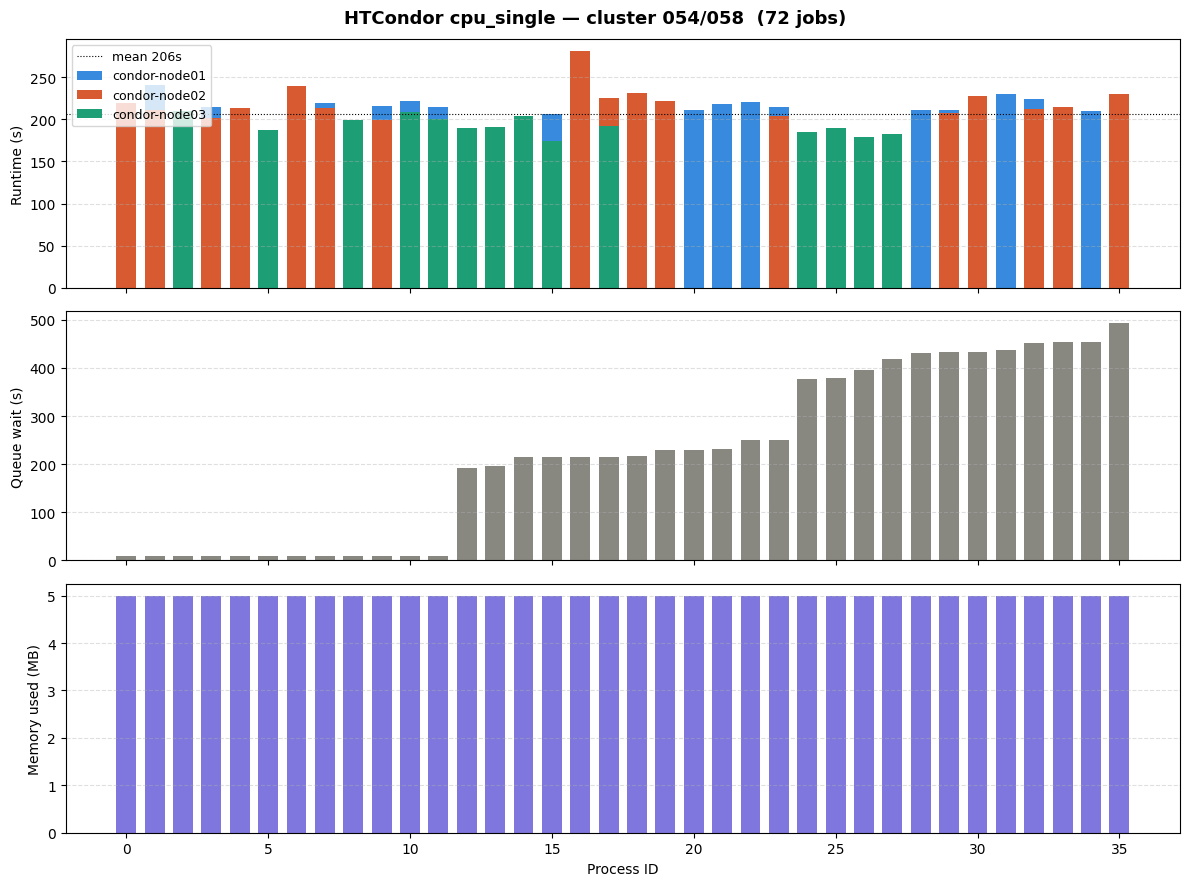


Summary (72 jobs):
  Runtime:    mean=206.0s  min=173s  max=281s  std=18.7s
  Queue wait: mean=215.4s  min=3s  max=493s
  Memory:     mean=5.0MB  max=5MB


In [9]:
# claude take the wheel, graph cpu_single results

import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from datetime import datetime

LOG_FILE = "/home/admin/cluster_benchmark/logs/cpu_single.log"

jobs = {}

# patterns
p_submit  = re.compile(r'000 \((\d+)\.(\d+)\.\d+\) ([\d-]+ [\d:]+) Job submitted')
p_execute = re.compile(
    r'001 \((\d+)\.(\d+)\.\d+\) ([\d-]+ [\d:]+) Job executing.*?alias=([\w-]+)',
    re.DOTALL
)
p_term    = re.compile(r'005 \((\d+)\.(\d+)\.\d+\) ([\d-]+ [\d:]+) Job terminated')
p_cpu     = re.compile(r'Usr 0 (\d+):(\d+):(\d+),.*?Run Remote Usage')
p_mem     = re.compile(r'Memory \(MB\)\s+:\s+(\d+)')
p_texec   = re.compile(r'TimeExecute \(s\)\s+:\s+(\d+)')

with open(LOG_FILE) as f:
    content = f.read()

# split into per-event blocks
blocks = content.split('\n...\n')

for block in blocks:
    m = p_submit.search(block)
    if m:
        key = (m.group(1), m.group(2))
        jobs.setdefault(key, {})['submit_time'] = datetime.strptime(m.group(3), '%Y-%m-%d %H:%M:%S')

    m = p_execute.search(block)
    if m:
        key = (m.group(1), m.group(2))
        jobs.setdefault(key, {})['start_time'] = datetime.strptime(m.group(3), '%Y-%m-%d %H:%M:%S')
        jobs[key]['node'] = m.group(4)

    m = p_term.search(block)
    if m:
        key = (m.group(1), m.group(2))
        jobs.setdefault(key, {})['end_time'] = datetime.strptime(m.group(3), '%Y-%m-%d %H:%M:%S')
        mc = p_cpu.search(block)
        if mc:
            jobs[key]['cpu_s'] = int(mc.group(1))*3600 + int(mc.group(2))*60 + int(mc.group(3))
        mm = p_mem.search(block)
        if mm:
            jobs[key]['mem_mb'] = int(mm.group(1))
        mt = p_texec.search(block)
        if mt:
            jobs[key]['texec'] = int(mt.group(1))

# build arrays for completed jobs only
completed = {k: v for k, v in jobs.items() if all(x in v for x in ['submit_time','start_time','end_time','texec'])}

proc_ids   = [int(k[1]) for k in completed]
queue_wait = [(v['start_time'] - v['submit_time']).total_seconds() for v in completed.values()]
runtime    = [v['texec'] for v in completed.values()]
mem_mb     = [v.get('mem_mb', 0) for v in completed.values()]
nodes      = [v.get('node', 'unknown') for v in completed.values()]
cpu_s      = [v.get('cpu_s', 0) for v in completed.values()]

# sort by proc id
order = np.argsort(proc_ids)
proc_ids   = np.array(proc_ids)[order]
queue_wait = np.array(queue_wait)[order]
runtime    = np.array(runtime)[order]
mem_mb     = np.array(mem_mb)[order]
nodes      = np.array(nodes)[order]
cpu_s      = np.array(cpu_s)[order]

node_names = sorted(set(nodes))
colors = {'condor-node01': '#378ADD', 'condor-node02': '#D85A30', 'condor-node03': '#1D9E75'}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"HTCondor cpu_single — cluster 054/058  ({len(completed)} jobs)", fontsize=13, fontweight="bold")

# runtime
for node in node_names:
    mask = nodes == node
    axes[0].bar(proc_ids[mask], runtime[mask], color=colors.get(node, 'gray'), label=node, width=0.7)
axes[0].set_ylabel("Runtime (s)")
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].axhline(np.mean(runtime), color='black', linewidth=0.8, linestyle=':', label=f'mean {np.mean(runtime):.0f}s')
axes[0].legend(fontsize=9)

# queue wait
axes[1].bar(proc_ids, queue_wait, color='#888780', width=0.7)
axes[1].set_ylabel("Queue wait (s)")
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# memory
axes[2].bar(proc_ids, mem_mb, color='#7F77DD', width=0.7)
axes[2].set_ylabel("Memory used (MB)")
axes[2].set_xlabel("Process ID")
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("condor_cpu_single.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSummary ({len(completed)} jobs):")
print(f"  Runtime:    mean={np.mean(runtime):.1f}s  min={np.min(runtime)}s  max={np.max(runtime)}s  std={np.std(runtime):.1f}s")
print(f"  Queue wait: mean={np.mean(queue_wait):.1f}s  min={np.min(queue_wait):.0f}s  max={np.max(queue_wait):.0f}s")
print(f"  Memory:     mean={np.mean(mem_mb):.1f}MB  max={np.max(mem_mb)}MB")

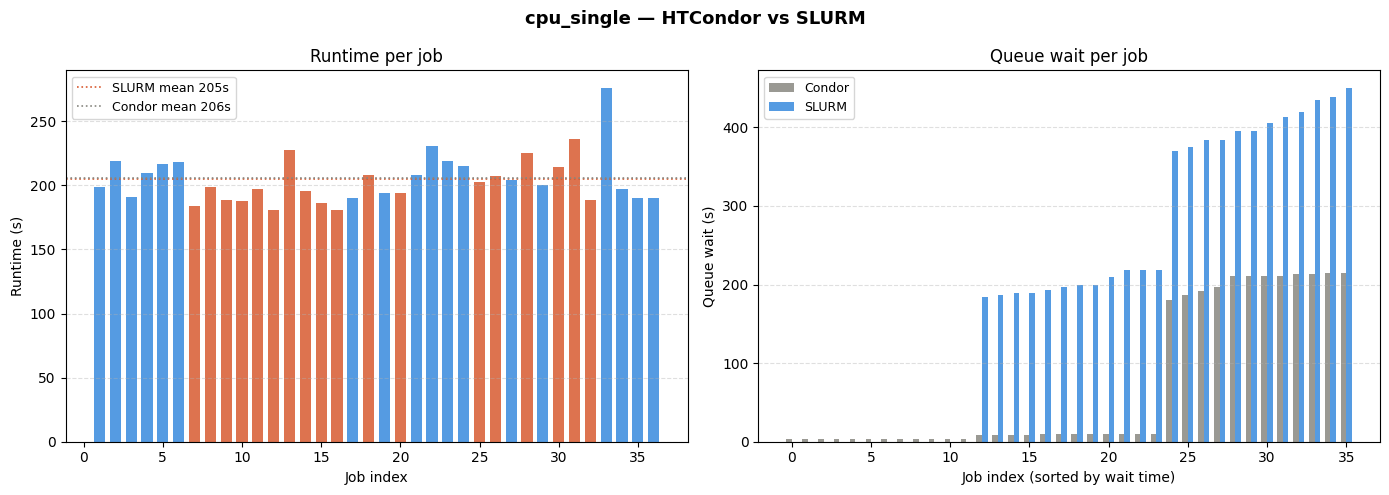


                          SLURM     Condor
Runtime mean (s)          204.8      206.1
Runtime std (s)            18.8       20.7
Queue wait mean (s)       201.9       72.5
Queue wait max (s)        450.0      215.0
Memory mean (MB)            5.4        5.0


In [10]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

sacct_data = """138_1  cpu_single  slurm01 2026-06-08T11:43:55 2026-06-08T11:47:14  00:03:19  4884K  COMPLETED
138_2  cpu_single  slurm01 2026-06-08T11:43:55 2026-06-08T11:47:34  00:03:39  4884K  COMPLETED
138_3  cpu_single  slurm01 2026-06-08T11:43:55 2026-06-08T11:47:06  00:03:11  4884K  COMPLETED
138_4  cpu_single  slurm01 2026-06-08T11:43:55 2026-06-08T11:47:25  00:03:30  4884K  COMPLETED
138_5  cpu_single  slurm01 2026-06-08T11:43:55 2026-06-08T11:47:32  00:03:37  4888K  COMPLETED
138_6  cpu_single  slurm01 2026-06-08T11:43:55 2026-06-08T11:47:33  00:03:38  4884K  COMPLETED
138_7  cpu_single  slurm02 2026-06-08T11:43:55 2026-06-08T11:46:59  00:03:04  7984K  COMPLETED
138_8  cpu_single  slurm02 2026-06-08T11:43:55 2026-06-08T11:47:14  00:03:19  4908K  COMPLETED
138_9  cpu_single  slurm02 2026-06-08T11:43:55 2026-06-08T11:47:04  00:03:09  8752K  COMPLETED
138_10 cpu_single  slurm02 2026-06-08T11:43:55 2026-06-08T11:47:03  00:03:08  7984K  COMPLETED
138_11 cpu_single  slurm02 2026-06-08T11:43:55 2026-06-08T11:47:12  00:03:17  4912K  COMPLETED
138_12 cpu_single  slurm02 2026-06-08T11:43:55 2026-06-08T11:46:56  00:03:01  4916K  COMPLETED
138_13 cpu_single  slurm02 2026-06-08T11:46:59 2026-06-08T11:50:47  00:03:48  4920K  COMPLETED
138_14 cpu_single  slurm02 2026-06-08T11:47:02 2026-06-08T11:50:18  00:03:16  8752K  COMPLETED
138_15 cpu_single  slurm02 2026-06-08T11:47:04 2026-06-08T11:50:10  00:03:06  8748K  COMPLETED
138_16 cpu_single  slurm02 2026-06-08T11:47:04 2026-06-08T11:50:05  00:03:01  8752K  COMPLETED
138_17 cpu_single  slurm01 2026-06-08T11:47:08 2026-06-08T11:50:18  00:03:10  4884K  COMPLETED
138_18 cpu_single  slurm02 2026-06-08T11:47:12 2026-06-08T11:50:40  00:03:28  4912K  COMPLETED
138_19 cpu_single  slurm01 2026-06-08T11:47:15 2026-06-08T11:50:29  00:03:14  4884K  COMPLETED
138_20 cpu_single  slurm02 2026-06-08T11:47:15 2026-06-08T11:50:29  00:03:14  4920K  COMPLETED
138_21 cpu_single  slurm01 2026-06-08T11:47:25 2026-06-08T11:50:53  00:03:28  4888K  COMPLETED
138_22 cpu_single  slurm01 2026-06-08T11:47:33 2026-06-08T11:51:24  00:03:51  4884K  COMPLETED
138_23 cpu_single  slurm01 2026-06-08T11:47:34 2026-06-08T11:51:13  00:03:39  4896K  COMPLETED
138_24 cpu_single  slurm01 2026-06-08T11:47:34 2026-06-08T11:51:09  00:03:35  4884K  COMPLETED
138_25 cpu_single  slurm02 2026-06-08T11:50:05 2026-06-08T11:53:28  00:03:23  4912K  COMPLETED
138_26 cpu_single  slurm02 2026-06-08T11:50:10 2026-06-08T11:53:37  00:03:27  4916K  COMPLETED
138_27 cpu_single  slurm01 2026-06-08T11:50:19 2026-06-08T11:53:43  00:03:24  4888K  COMPLETED
138_28 cpu_single  slurm02 2026-06-08T11:50:19 2026-06-08T11:54:04  00:03:45  4912K  COMPLETED
138_29 cpu_single  slurm01 2026-06-08T11:50:30 2026-06-08T11:53:50  00:03:20  4884K  COMPLETED
138_30 cpu_single  slurm02 2026-06-08T11:50:30 2026-06-08T11:54:04  00:03:34  4912K  COMPLETED
138_31 cpu_single  slurm02 2026-06-08T11:50:40 2026-06-08T11:54:36  00:03:56  4912K  COMPLETED
138_32 cpu_single  slurm02 2026-06-08T11:50:48 2026-06-08T11:53:57  00:03:09  4912K  COMPLETED
138_33 cpu_single  slurm01 2026-06-08T11:50:54 2026-06-08T11:55:30  00:04:36  4892K  COMPLETED
138_34 cpu_single  slurm01 2026-06-08T11:51:10 2026-06-08T11:54:27  00:03:17  4892K  COMPLETED
138_35 cpu_single  slurm01 2026-06-08T11:51:14 2026-06-08T11:54:24  00:03:10  4884K  COMPLETED
138_36 cpu_single  slurm01 2026-06-08T11:51:25 2026-06-08T11:54:35  00:03:10  4892K  COMPLETED"""

fmt = '%Y-%m-%dT%H:%M:%S'
slurm = []
for line in sacct_data.strip().splitlines():
    parts = line.split()
    job_id  = int(parts[0].split('_')[1])
    node    = parts[2]
    start   = datetime.strptime(parts[3], fmt)
    end     = datetime.strptime(parts[4], fmt)
    elapsed = (end - start).total_seconds()
    mem_kb  = int(parts[6].replace('K',''))
    slurm.append({'id': job_id, 'node': node, 'start': start,
                  'end': end, 'runtime': elapsed, 'mem_mb': mem_kb / 1024})

slurm.sort(key=lambda x: x['id'])
submit_time = datetime.strptime('2026-06-08T11:43:55', fmt)  # all submitted together

s_ids     = [j['id'] for j in slurm]
s_runtime = [j['runtime'] for j in slurm]
s_wait    = [(j['start'] - submit_time).total_seconds() for j in slurm]
s_mem     = [j['mem_mb'] for j in slurm]
s_nodes   = [j['node'] for j in slurm]

# --- condor data from earlier parse (reuse your existing arrays) ---
# proc_ids, runtime, queue_wait, mem_mb, nodes  <-- already in memory

node_colors = {'slurm01': '#378ADD', 'slurm02': '#D85A30',
               'condor-node01': '#378ADD', 'condor-node02': '#D85A30', 'condor-node03': '#1D9E75'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("cpu_single — HTCondor vs SLURM", fontsize=13, fontweight="bold")

# --- runtime comparison ---
ax = axes[0]
ax.set_title("Runtime per job")
for j in slurm:
    ax.bar(j['id'], j['runtime'], color=node_colors[j['node']], width=0.7, alpha=0.85)
ax.axhline(np.mean(s_runtime), color='#D85A30', linestyle=':', linewidth=1.2,
           label=f"SLURM mean {np.mean(s_runtime):.0f}s")
ax.axhline(np.mean(runtime), color='#888780', linestyle=':', linewidth=1.2,
           label=f"Condor mean {np.mean(runtime):.0f}s")
ax.set_xlabel("Job index")
ax.set_ylabel("Runtime (s)")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- queue wait comparison ---
ax = axes[1]
ax.set_title("Queue wait per job")
x = np.arange(36)
w = 0.35
ax.bar(x - w/2, sorted(queue_wait[:36]), width=w, color='#888780', alpha=0.85, label='Condor')
ax.bar(x + w/2, sorted(s_wait),          width=w, color='#378ADD', alpha=0.85, label='SLURM')
ax.set_xlabel("Job index (sorted by wait time)")
ax.set_ylabel("Queue wait (s)")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("condor_vs_slurm_cpu_single.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'':20} {'SLURM':>10} {'Condor':>10}")
print(f"{'Runtime mean (s)':20} {np.mean(s_runtime):>10.1f} {np.mean(runtime[:36]):>10.1f}")
print(f"{'Runtime std (s)':20} {np.std(s_runtime):>10.1f} {np.std(runtime[:36]):>10.1f}")
print(f"{'Queue wait mean (s)':20} {np.mean(s_wait):>10.1f} {np.mean(queue_wait[:36]):>10.1f}")
print(f"{'Queue wait max (s)':20} {np.max(s_wait):>10.1f} {np.max(queue_wait[:36]):>10.1f}")
print(f"{'Memory mean (MB)':20} {np.mean(s_mem):>10.1f} {np.mean(mem_mb[:36]):>10.1f}")